# Modelado con Pyspark

En esta etapa se desarrolla el modelo de clasificación binaria mediante una red neuronal MLP utilizando PySpark, aprovechando su capacidad para procesar grandes volúmenes de datos de manera distribuida. De esta forma, se realiza el preprocesamiento de las variables, la transformación de las características y el entrenamiento de diferentes configuraciones del modelo. Posteriormente, las configuraciones son evaluadas mediante métricas como Accuracy, Precision, Recall, F1-Score y ROC AUC, además del tiempo de ejecución. Finalmente, se comparan los resultados obtenidos para seleccionar y conservar el modelo con mejor desempeño.
Cabe recalcar que este modelado es análogo al hecho con Scikit-Learn en la sección anterior.

In [1]:
import os
os.environ["HADOOP_HOME"] = "C:\\hadoop"
os.environ["PATH"] = os.environ["HADOOP_HOME"] + "\\bin;" + os.environ["PATH"]

In [ ]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import time
import pandas as pd
from pyspark import StorageLevel
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark import StorageLevel
from pyspark.ml.classification import MultilayerPerceptronClassificationModel
import json
import shutil
from pyspark.ml.classification import MultilayerPerceptronClassificationModel


## Leer el CSV utilizando SparkSession  

En este bloque se configura SparkSession para trabajar con el conjunto de datos Avazu utilizando PySpark. Se asignan recursos de memoria y configuraciones adicionales para facilitar el procesamiento de un dataset de gran tamaño. Posteriormente, se carga train.csv utilizando Spark, activando la lectura del encabezado y la inferencia automática de los tipos de datos. Finalmente, se consulta el número de filas y columnas y se muestra el esquema del dataset para verificar que la información haya sido cargada correctamente.

In [3]:
spark = SparkSession.builder \
    .appName("Avazu_PySpark") \
    .master("local[6]") \
    .config("spark.driver.memory", "16g") \
    .config("spark.driver.maxResultSize", "1g") \
    .config("spark.sql.shuffle.partitions", "48") \
    .config("spark.local.dir", "C:/spark_tmp") \
    .config("spark.driver.extraJavaOptions",
            "-XX:+UseG1GC "
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.lang.invoke=ALL-UNNAMED "
            "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED "
            "--add-opens=java.base/java.io=ALL-UNNAMED "
            "--add-opens=java.base/java.net=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "--add-opens=java.base/java.util.concurrent=ALL-UNNAMED "
            "--add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED "
            "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED "
            "--add-opens=java.base/sun.nio.cs=ALL-UNNAMED "
            "--add-opens=java.base/sun.security.action=ALL-UNNAMED "
            "--add-opens=java.base/sun.util.calendar=ALL-UNNAMED") \
    .config("spark.network.timeout", "600s") \
    .config("spark.executor.heartbeatInterval", "60s") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
spark
df_train = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("../data/train.csv")

print(f"Filas: {df_train.count():,} | Columnas: {len(df_train.columns)}")
df_train.printSchema()

Filas: 40,428,967 | Columnas: 24
root
 |-- id: decimal(20,0) (nullable = true)
 |-- click: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- C1: integer (nullable = true)
 |-- banner_pos: integer (nullable = true)
 |-- site_id: string (nullable = true)
 |-- site_domain: string (nullable = true)
 |-- site_category: string (nullable = true)
 |-- app_id: string (nullable = true)
 |-- app_domain: string (nullable = true)
 |-- app_category: string (nullable = true)
 |-- device_id: string (nullable = true)
 |-- device_ip: string (nullable = true)
 |-- device_model: string (nullable = true)
 |-- device_type: integer (nullable = true)
 |-- device_conn_type: integer (nullable = true)
 |-- C14: integer (nullable = true)
 |-- C15: integer (nullable = true)
 |-- C16: integer (nullable = true)
 |-- C17: integer (nullable = true)
 |-- C18: integer (nullable = true)
 |-- C19: integer (nullable = true)
 |-- C20: integer (nullable = true)
 |-- C21: integer (nullable = true)



In [4]:
print(spark.version)
print(spark.range(10).count())

4.0.2
10


# Preprocesamiento

## Ingeniería de características  

En este bloque se transforma la variable hour para obtener nuevas variables temporales: día (day), hora del día (hour_of_day) y franja horaria.

Las franjas se clasifican en Madrugada, Mañana, Tarde y Noche. Además, se eliminan variables que no serán utilizadas en el modelo, como id, hour, device_ip y device_id, reduciendo así la dimensionalidad y evitando trabajar con variables de alta cardinalidad.

In [5]:
df_train_1 = df_train.withColumn("hour_str", F.col("hour").cast("string"))

df_prep = df_train_1 \
    .withColumn("day", F.substring("hour_str", 5, 2).cast("integer")) \
    .withColumn("hour_of_day", F.substring("hour_str", 7, 2).cast("integer")) \
    .withColumn(
        "franja_horaria",
        F.when((F.col("hour_of_day") >= 0)  & (F.col("hour_of_day") < 6),  "Madrugada")
         .when((F.col("hour_of_day") >= 6)  & (F.col("hour_of_day") < 12), "Mañana")
         .when((F.col("hour_of_day") >= 12) & (F.col("hour_of_day") < 18), "Tarde")
         .otherwise("Noche")
    ) \
    .drop("hour_str", "hour", "id", "device_ip", "device_id")

df_prep.printSchema()

root
 |-- click: integer (nullable = true)
 |-- C1: integer (nullable = true)
 |-- banner_pos: integer (nullable = true)
 |-- site_id: string (nullable = true)
 |-- site_domain: string (nullable = true)
 |-- site_category: string (nullable = true)
 |-- app_id: string (nullable = true)
 |-- app_domain: string (nullable = true)
 |-- app_category: string (nullable = true)
 |-- device_model: string (nullable = true)
 |-- device_type: integer (nullable = true)
 |-- device_conn_type: integer (nullable = true)
 |-- C14: integer (nullable = true)
 |-- C15: integer (nullable = true)
 |-- C16: integer (nullable = true)
 |-- C17: integer (nullable = true)
 |-- C18: integer (nullable = true)
 |-- C19: integer (nullable = true)
 |-- C20: integer (nullable = true)
 |-- C21: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- hour_of_day: integer (nullable = true)
 |-- franja_horaria: string (nullable = false)



## División train/test  

En esta etapa se divide el conjunto de datos en dos subconjuntos mediante randomSplit, utilizando una proporción de 80% para entrenamiento y 20% para prueba.

Se utiliza seed=42 para garantizar que la división sea reproducible. El conjunto de entrenamiento será utilizado para ajustar el procesamiento y entrenar los modelos, mientras que el conjunto de prueba permitirá evaluar su desempeño.

In [6]:
train, test = df_prep.randomSplit([0.8, 0.2], seed=42)

print(f"Train: {train.count():,} filas")
print(f"Test:  {test.count():,} filas")

Train: 32,344,946 filas
Test:  8,084,021 filas


## Variables categóricas y codificación  

En este bloque se preparan las variables categóricas para que puedan ser utilizadas por la red neuronal. Algunas variables originalmente numéricas, como C1, C14 y otras variables C, se convierten a texto para tratarlas como categorías. Para las variables con alta cardinalidad se aplica una reducción mediante Top-K, conservando únicamente las categorías más frecuentes y agrupando las restantes bajo la categoría "Otros". Los valores de Top-K utilizados son 30 para las variables de alta cardinalidad y 20 para las de cardinalidad media.  
Posteriormente, las variables categóricas se transforman mediante StringIndexer y OneHotEncoder. El proceso se ajusta utilizando únicamente el conjunto de entrenamiento y luego se aplica tanto a entrenamiento como a prueba.

In [ ]:
# convertimos a texto algunas variables como c1, c14, etc
# para tratarlas como categóricas.
cols_a_castear = ["C1", "banner_pos", "device_type", "device_conn_type",
                   "C14", "C15", "C16", "C17", "C18", "C19", "C20", "C21"]

for c in cols_a_castear:
    train = train.withColumn(c, F.col(c).cast("string"))
    test  = test.withColumn(c, F.col(c).cast("string"))


train = train.persist(StorageLevel.DISK_ONLY)
test  = test.persist(StorageLevel.DISK_ONLY)
print("Train guardado:", train.count())
print("Test guardado:", test.count())

# Definimos los grupos de columnas según su cardinalidad.
cols_topk_high   = ["site_id", "site_domain", "app_id", "app_domain", "device_model", "C14"]  
cols_topk_medium = ["C17", "C19", "C20", "C21"]                                                 
cols_onehot_direct = ["C1", "banner_pos", "site_category", "app_category",
                       "device_type", "device_conn_type", "C15", "C16",
                       "C18", "franja_horaria"]

k_dict = {**{c: 30 for c in cols_topk_high}, **{c: 20 for c in cols_topk_medium}}

# Función que calcula las K categorías más frecuentes de una columna
# se calcula usando solo 'train'
def obtener_top_k(df, columna, k):
    filas = (df.groupBy(columna)
               .count()
               .orderBy(F.col("count").desc())
               .limit(k)
               .collect())
    return [fila[columna] for fila in filas]

top_k_dict = {}
for col in cols_topk_high + cols_topk_medium:
    top_k_dict[col] = obtener_top_k(train, col, k_dict[col])


# Función que aplica el agrupamiento: si el valor está en el top-k, se conserva;
# si no, se reemplaza por 'otros'
def aplicar_topk(df, top_k_dict, categoria_otros="Otros"):
    for col, top_vals in top_k_dict.items():
        df = df.withColumn(
            col,
            F.when(F.col(col).isin(top_vals), F.col(col)).otherwise(categoria_otros)
        )
    return df

train = aplicar_topk(train, top_k_dict)
test  = aplicar_topk(test, top_k_dict)


cols_categoricas = cols_topk_high + cols_topk_medium + cols_onehot_direct

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in cols_categoricas
]

encoders = [
    OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
    for c in cols_categoricas
]

pipeline_encoding = Pipeline(stages=indexers + encoders)
encoding_model = pipeline_encoding.fit(train)

train_enc = encoding_model.transform(train)
test_enc  = encoding_model.transform(test)

train_enc.select([f"{c}_ohe" for c in cols_categoricas[:3]]).show(5, truncate=False)

Train guardado: 32344946
Test guardado: 8084021
+--------------+---------------+--------------+
|site_id_ohe   |site_domain_ohe|app_id_ohe    |
+--------------+---------------+--------------+
|(31,[1],[1.0])|(31,[0],[1.0]) |(31,[0],[1.0])|
|(31,[1],[1.0])|(31,[0],[1.0]) |(31,[0],[1.0])|
|(31,[1],[1.0])|(31,[0],[1.0]) |(31,[0],[1.0])|
|(31,[1],[1.0])|(31,[0],[1.0]) |(31,[0],[1.0])|
|(31,[1],[1.0])|(31,[0],[1.0]) |(31,[0],[1.0])|
+--------------+---------------+--------------+
only showing top 5 rows


## Combinación de características mediante VectorAssembler  

Una vez codificadas las variables categóricas, se utiliza VectorAssembler para combinarlas en un único vector de características.

Las variables categóricas codificadas se agrupan en cat_features, mientras que las variables numéricas day y hour_of_day se agrupan en num_features. Esto permite preparar los datos para el procesamiento posterior y su entrada al modelo MLP.

In [ ]:
# Grupo 1: todas las columnas categóricas ya codificadas.
cols_ohe = [f"{c}_ohe" for c in cols_categoricas]

assembler_cat = VectorAssembler(
    inputCols=cols_ohe,
    outputCol="cat_features"
)

# Grupo 2: las columnas numéricas (day, hour_of_day)
cols_numeric = ["day", "hour_of_day"]

assembler_num = VectorAssembler(
    inputCols=cols_numeric,
    outputCol="num_features"
)

# Aplicamos los dos ensambladores sobre train y test.
train_vec = assembler_cat.transform(train_enc)
train_vec = assembler_num.transform(train_vec)

test_vec = assembler_cat.transform(test_enc)
test_vec = assembler_num.transform(test_vec)

train_vec.select("cat_features", "num_features").show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------+
|cat_features                                                                                                                                                        |num_features|
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------+
|(380,[1,31,62,93,144,155,186,215,229,255,275,277,307,310,346,351,355,363,373,378],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])|[21.0,0.0]  |
|(380,[1,31,62,93,144,155,186,212,229,269,275,277,301,310,346,351,355,363,373,378],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])|[21.0,0.0]  |
|(380,[1,31,62,93,144,155,186,215,228,255,275,277,301,310,346,351,355,363,373,378],[1.0,1.0,1.0,1.0,

## Estandarización de las variables numéricas

En este bloque se aplica StandardScaler a las variables numéricas previamente agrupadas. La media y la desviación estándar se calculan utilizando únicamente el conjunto de entrenamiento. Posteriormente, estos mismos parámetros se utilizan para transformar tanto los datos de entrenamiento como los de prueba, evitando introducir información del conjunto de prueba durante el procesamiento.

In [ ]:
scaler = StandardScaler(
    inputCol="num_features",
    outputCol="num_features_scaled",
    withMean=True,
    withStd=True
)

# aquí es donde calculé la media y la desviación estándar
scaler_model = scaler.fit(train_vec)

# transform (sin volver a aprender nada) sobre train y test
train_vec = scaler_model.transform(train_vec)
test_vec  = scaler_model.transform(test_vec)

train_vec.select("num_features", "num_features_scaled").show(5, truncate=False)

+------------+----------------------------------------+
|num_features|num_features_scaled                     |
+------------+----------------------------------------+
|[21.0,0.0]  |[-1.5083131702996149,-1.894332327485861]|
|[21.0,0.0]  |[-1.5083131702996149,-1.894332327485861]|
|[21.0,0.0]  |[-1.5083131702996149,-1.894332327485861]|
|[21.0,0.0]  |[-1.5083131702996149,-1.894332327485861]|
|[21.0,0.0]  |[-1.5083131702996149,-1.894332327485861]|
+------------+----------------------------------------+
only showing top 5 rows


En esta etapa se combinan las características categóricas codificadas y las variables numéricas estandarizadas en un único vector denominado features. Este vector constituye la entrada que utilizará el Multilayer Perceptron Classifier. Finalmente, se verifica su dimensión para conocer el número de características que recibirá la red neuronal.

In [10]:
assembler_final = VectorAssembler(
    inputCols=["cat_features", "num_features_scaled"],
    outputCol="features"
)

train_final = assembler_final.transform(train_vec)
test_final  = assembler_final.transform(test_vec)

# Vector final que usará el modelo, y la columna objetivo
train_final.select("features", "click").show(5, truncate=False)

# Cuántas dimensiones tiene el vector de entrada
print("Dimensión del vector 'features':", train_final.select("features").first()["features"].size)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|features                                                                                                                                                                                                           |click|
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|(382,[1,31,62,93,144,155,186,215,229,255,275,277,307,310,346,351,355,363,373,378,380,381],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.5083131702996149,-1.894332327485861])|0    |
|(382,[1,31,62,93,144,155,186,212,229,269,275,277,301,310,346,351,355,363,373,378,380,381],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,

Se almacenan los conjuntos de entrenamiento y prueba utilizando StorageLevel.MEMORY_AND_DISK. Esto permite conservar los datos procesados y reutilizarlos durante el entrenamiento de las diferentes configuraciones del modelo, reduciendo la necesidad de repetir las transformaciones anteriores.  

In [ ]:
train_final = train_final.persist(StorageLevel.MEMORY_AND_DISK) 
test_final = test_final.persist(StorageLevel.MEMORY_AND_DISK)

print("Filas train:", train_final.count())
print("Filas test:", test_final.count())

Filas train: 32344946
Filas test: 8084021


## Definición del entrenamiento

En este bloque se define la búsqueda de hiperparámetros para el MultilayerPerceptronClassifier de PySpark.

Se evalúan tres tamaños de capa oculta: 10, 50 y 100 neuronas, dos valores de stepSize (0.1 y 0.01) y dos valores de maxIter (100 y 200). En total se generan:

$$
3 \times 2 \times 2 = 12
$$

configuraciones.

Para cada combinación se entrena el modelo, se mide el tiempo de entrenamiento y posteriormente se realizan las predicciones sobre el conjunto de prueba. Se calculan Accuracy, Precision, Recall, F1-Score y ROC AUC, además de almacenar la matriz de confusión.

Cada modelo y sus resultados se guardan individualmente mediante checkpoints, permitiendo conservar el progreso y evitar repetir configuraciones que ya hayan sido evaluadas.

In [ ]:
num_features = 382

# Las 12 combinaciones que pide el enunciado
param_grid = []
for neuronas_capa_oculta in [10, 50, 100]:
    for step in [0.1, 0.01]:
        for it in [100, 200]:
            param_grid.append({
                "layers": [num_features, neuronas_capa_oculta, 2],
                "stepSize": step,
                "maxIter": it
            })
print(f"Total de combinaciones: {len(param_grid)}")

checkpoint_dir = "../checkpoints/pyspark"
os.makedirs(checkpoint_dir, exist_ok=True)
results_path = os.path.join(checkpoint_dir, "resultados_gridsearch_pyspark.csv")

if os.path.exists(results_path):
    resultados_df = pd.read_csv(results_path)
    combinaciones_evaluadas = set(
        zip(resultados_df["layers"], resultados_df["stepSize"], resultados_df["maxIter"])
    )
else:
    resultados_df = pd.DataFrame(columns=[
        "iteracion", "layers", "stepSize", "maxIter",
        "accuracy", "precision", "recall", "f1_score", "roc_auc",
        "train_time_seg", "predict_time_seg", "modelo_path"
    ])
    combinaciones_evaluadas = set()

for i, params in enumerate(param_grid, start=1):
    combo_key = (str(params["layers"]), params["stepSize"], params["maxIter"])
    if combo_key in combinaciones_evaluadas:
        print(f"[{i}/{len(param_grid)}] Ya evaluado, se omite: {params}")
        continue

    print(f"[{i}/{len(param_grid)}] Entrenando con: {params}")

    mlp = MultilayerPerceptronClassifier(
        featuresCol="features",
        labelCol="click",
        layers=params["layers"],
        stepSize=params["stepSize"],
        maxIter=params["maxIter"],
        seed=42
    )

    # --- Entrenamiento ---
    t0 = time.time()
    mlp_model = mlp.fit(train_final)
    train_time = time.time() - t0

    # --- Guardar el modelo YA entrenado, ANTES de seguir con la predicción ---
    model_path = os.path.join(checkpoint_dir, f"mlp_model_iter{i}")
    mlp_model.write().overwrite().save(model_path)

    # --- Predicción ---
    t0 = time.time()
    predictions = mlp_model.transform(test_final)
    # Nos quedamos solo con las columnas que de verdad necesitamos:
    # descartamos el vector "features" (382 números por fila) que ya no hace falta.
    predictions = predictions.select("click", "rawPrediction", "prediction", "probability")
    predictions = predictions.persist(StorageLevel.DISK_ONLY)
    predictions.count()  # fuerza el cálculo real aquí, y así medimos el tiempo real
    predict_time = time.time() - t0

    # --- Métricas (Precision/Recall/F1 sobre la clase 1 = click, por el desbalance) ---
    evaluator_auc  = BinaryClassificationEvaluator(labelCol="click", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    evaluator_acc  = MulticlassClassificationEvaluator(labelCol="click", predictionCol="prediction", metricName="accuracy")
    evaluator_prec = MulticlassClassificationEvaluator(labelCol="click", predictionCol="prediction", metricName="precisionByLabel", metricLabel=1.0)
    evaluator_rec  = MulticlassClassificationEvaluator(labelCol="click", predictionCol="prediction", metricName="recallByLabel", metricLabel=1.0)
    evaluator_f1   = MulticlassClassificationEvaluator(labelCol="click", predictionCol="prediction", metricName="fMeasureByLabel", metricLabel=1.0)

    auc  = evaluator_auc.evaluate(predictions)
    acc  = evaluator_acc.evaluate(predictions)
    prec = evaluator_prec.evaluate(predictions)
    rec  = evaluator_rec.evaluate(predictions)
    f1   = evaluator_f1.evaluate(predictions)

    # --- Matriz de confusión ---
    cm = predictions.groupBy("click", "prediction").count().toPandas()
    cm.to_csv(os.path.join(checkpoint_dir, f"cm_iter{i}.csv"), index=False)

    # --- Checkpoint de resultados: se guarda tras CADA combinación ---
    nueva_fila = {
        "iteracion": i, "layers": str(params["layers"]),
        "stepSize": params["stepSize"], "maxIter": params["maxIter"],
        "accuracy": acc, "precision": prec, "recall": rec,
        "f1_score": f1, "roc_auc": auc,
        "train_time_seg": train_time, "predict_time_seg": predict_time,
        "modelo_path": model_path,
    }
    resultados_df = pd.concat([resultados_df, pd.DataFrame([nueva_fila])], ignore_index=True)
    resultados_df.to_csv(results_path, index=False)

    predictions.unpersist()  # libera memoria antes de la siguiente combinación

    print(f"   -> AUC: {auc:.4f} | F1: {f1:.4f} | Recall: {rec:.4f} | "
          f"Train: {train_time:.1f}s | Predict: {predict_time:.2f}s")

print("\nBúsqueda completada.")
resultados_df.sort_values("roc_auc", ascending=False)

Total de combinaciones: 12
[1/12] Entrenando con: {'layers': [382, 10, 2], 'stepSize': 0.1, 'maxIter': 100}


C:\Users\MSI TRUE GAMING\AppData\Local\Temp\ipykernel_5480\2611690844.py:101: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  resultados_df = pd.concat([resultados_df, pd.DataFrame([nueva_fila])], ignore_index=True)


   -> AUC: 0.6954 | F1: 0.0892 | Recall: 0.0484 | Train: 3108.6s | Predict: 12.32s
[2/12] Entrenando con: {'layers': [382, 10, 2], 'stepSize': 0.1, 'maxIter': 200}
   -> AUC: 0.6941 | F1: 0.1102 | Recall: 0.0610 | Train: 6243.4s | Predict: 11.82s
[3/12] Entrenando con: {'layers': [382, 10, 2], 'stepSize': 0.01, 'maxIter': 100}
   -> AUC: 0.6954 | F1: 0.0892 | Recall: 0.0484 | Train: 3130.6s | Predict: 10.92s
[4/12] Entrenando con: {'layers': [382, 10, 2], 'stepSize': 0.01, 'maxIter': 200}
   -> AUC: 0.6938 | F1: 0.1045 | Recall: 0.0574 | Train: 7860.8s | Predict: 14.43s
[5/12] Entrenando con: {'layers': [382, 50, 2], 'stepSize': 0.1, 'maxIter': 100}
   -> AUC: 0.7188 | F1: 0.0889 | Recall: 0.0482 | Train: 7623.6s | Predict: 25.49s
[6/12] Entrenando con: {'layers': [382, 50, 2], 'stepSize': 0.1, 'maxIter': 200}
   -> AUC: 0.7252 | F1: 0.0960 | Recall: 0.0524 | Train: 13899.3s | Predict: 21.61s
[7/12] Entrenando con: {'layers': [382, 50, 2], 'stepSize': 0.01, 'maxIter': 100}


In [ ]:
num_features = 382

# Las 12 combinaciones completas (igual que en tu notebook, para que coincidan)
param_grid_completo = []
for neuronas_capa_oculta in [10, 50, 100]:
    for step in [0.1, 0.01]:
        for it in [100, 200]:
            param_grid_completo.append({
                "layers": [num_features, neuronas_capa_oculta, 2],
                "stepSize": step,
                "maxIter": it
            })

# Le ponemos número real (1 al 12) a cada combinación
combos_numerados = list(enumerate(param_grid_completo, start=1))

# --- Esta es la parte de TU COMPAÑERO: combinaciones 7 a 12 ---
mi_parte = combos_numerados[6:12]

print(f"Voy a correr {len(mi_parte)} combinaciones: de la {mi_parte[0][0]} a la {mi_parte[-1][0]}")

checkpoint_dir = "../checkpoints/pyspark"
os.makedirs(checkpoint_dir, exist_ok=True)
results_path = os.path.join(checkpoint_dir, "resultados_gridsearch_pyspark.csv")

if os.path.exists(results_path):
    resultados_df = pd.read_csv(results_path)
    combinaciones_evaluadas = set(
        zip(resultados_df["layers"], resultados_df["stepSize"], resultados_df["maxIter"])
    )
else:
    resultados_df = pd.DataFrame(columns=[
        "iteracion", "layers", "stepSize", "maxIter",
        "accuracy", "precision", "recall", "f1_score", "roc_auc",
        "train_time_seg", "predict_time_seg", "modelo_path"
    ])
    combinaciones_evaluadas = set()

for i, params in mi_parte:
    combo_key = (str(params["layers"]), params["stepSize"], params["maxIter"])
    if combo_key in combinaciones_evaluadas:
        print(f"[{i}/12] Ya evaluado, se omite: {params}")
        continue

    print(f"[{i}/12] Entrenando con: {params}")

    mlp = MultilayerPerceptronClassifier(
        featuresCol="features",
        labelCol="click",
        layers=params["layers"],
        stepSize=params["stepSize"],
        maxIter=params["maxIter"],
        seed=42
    )

    # --- Entrenamiento ---
    t0 = time.time()
    mlp_model = mlp.fit(train_final)
    train_time = time.time() - t0

    # --- Guardar el modelo YA entrenado, ANTES de seguir con la predicción ---
    model_path = os.path.join(checkpoint_dir, f"mlp_model_iter{i}")
    mlp_model.write().overwrite().save(model_path)

    # --- Predicción ---
    t0 = time.time()
    predictions = mlp_model.transform(test_final)
    predictions = predictions.select("click", "rawPrediction", "prediction", "probability")
    predictions = predictions.persist(StorageLevel.DISK_ONLY)
    predictions.count()
    predict_time = time.time() - t0

    # --- Métricas ---
    evaluator_auc  = BinaryClassificationEvaluator(labelCol="click", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    evaluator_acc  = MulticlassClassificationEvaluator(labelCol="click", predictionCol="prediction", metricName="accuracy")
    evaluator_prec = MulticlassClassificationEvaluator(labelCol="click", predictionCol="prediction", metricName="precisionByLabel", metricLabel=1.0)
    evaluator_rec  = MulticlassClassificationEvaluator(labelCol="click", predictionCol="prediction", metricName="recallByLabel", metricLabel=1.0)
    evaluator_f1   = MulticlassClassificationEvaluator(labelCol="click", predictionCol="prediction", metricName="fMeasureByLabel", metricLabel=1.0)

    auc  = evaluator_auc.evaluate(predictions)
    acc  = evaluator_acc.evaluate(predictions)
    prec = evaluator_prec.evaluate(predictions)
    rec  = evaluator_rec.evaluate(predictions)
    f1   = evaluator_f1.evaluate(predictions)

    # --- Matriz de confusión ---
    cm = predictions.groupBy("click", "prediction").count().toPandas()
    cm.to_csv(os.path.join(checkpoint_dir, f"cm_iter{i}.csv"), index=False)

    # --- Checkpoint de resultados ---
    nueva_fila = {
        "iteracion": i, "layers": str(params["layers"]),
        "stepSize": params["stepSize"], "maxIter": params["maxIter"],
        "accuracy": acc, "precision": prec, "recall": rec,
        "f1_score": f1, "roc_auc": auc,
        "train_time_seg": train_time, "predict_time_seg": predict_time,
        "modelo_path": model_path,
    }
    resultados_df = pd.concat([resultados_df, pd.DataFrame([nueva_fila])], ignore_index=True)
    resultados_df.to_csv(results_path, index=False)

    predictions.unpersist()

    print(f"   -> AUC: {auc:.4f} | F1: {f1:.4f} | Recall: {rec:.4f} | "
          f"Train: {train_time:.1f}s | Predict: {predict_time:.2f}s")

print("\nBúsqueda completada (combinaciones 7-12).")
resultados_df.sort_values("roc_auc", ascending=False)

Voy a correr 6 combinaciones: de la 7 a la 12
[7/12] Entrenando con: {'layers': [382, 50, 2], 'stepSize': 0.01, 'maxIter': 100}


C:\Users\User\AppData\Local\Temp\ipykernel_11888\99296979.py:106: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  resultados_df = pd.concat([resultados_df, pd.DataFrame([nueva_fila])], ignore_index=True)


   -> AUC: 0.7188 | F1: 0.0890 | Recall: 0.0483 | Train: 5368.2s | Predict: 19.54s
[8/12] Entrenando con: {'layers': [382, 50, 2], 'stepSize': 0.01, 'maxIter': 200}
   -> AUC: 0.7244 | F1: 0.0926 | Recall: 0.0503 | Train: 10866.9s | Predict: 19.83s
[9/12] Entrenando con: {'layers': [382, 100, 2], 'stepSize': 0.1, 'maxIter': 100}
   -> AUC: 0.7181 | F1: 0.0809 | Recall: 0.0435 | Train: 7702.2s | Predict: 38.79s
[10/12] Entrenando con: {'layers': [382, 100, 2], 'stepSize': 0.1, 'maxIter': 200}
   -> AUC: 0.7237 | F1: 0.0896 | Recall: 0.0485 | Train: 16372.5s | Predict: 38.11s
[11/12] Entrenando con: {'layers': [382, 100, 2], 'stepSize': 0.01, 'maxIter': 100}
   -> AUC: 0.7181 | F1: 0.0809 | Recall: 0.0435 | Train: 8488.4s | Predict: 34.38s
[12/12] Entrenando con: {'layers': [382, 100, 2], 'stepSize': 0.01, 'maxIter': 200}
   -> AUC: 0.7238 | F1: 0.0888 | Recall: 0.0481 | Train: 13918.0s | Predict: 24.02s

Búsqueda completada (combinaciones 7-12).


,iteracion,layers,stepSize,maxIter,accuracy,precision,recall,f1_score,roc_auc,train_time_seg,predict_time_seg,modelo_path
1,8,"[382, 50, 2]",0.01,200,0.832858,0.581017,0.050296,0.092578,0.724366,10866.933154,19.830134,../checkpoints/pyspark\mlp_model_iter8
5,12,"[382, 100, 2]",0.01,200,0.832660,0.577179,0.048080,0.088766,0.723751,13918.026891,24.016714,../checkpoints/pyspark\mlp_model_iter12
3,10,"[382, 100, 2]",0.10,200,0.832672,0.576818,0.048547,0.089557,0.723731,16372.514315,38.113913,../checkpoints/pyspark\mlp_model_iter10
0,7,"[382, 50, 2]",0.01,100,0.832383,0.565793,0.048278,0.088966,0.718825,5368.204480,19.542085,../checkpoints/pyspark\mlp_model_iter7
4,11,"[382, 100, 2]",0.01,100,0.832403,0.575025,0.043484,0.080854,0.718145,8488.350915,34.376172,../checkpoints/pyspark\mlp_model_iter11
2,9,"[382, 100, 2]",0.10,100,0.832403,0.575025,0.043484,0.080854,0.718145,7702.225971,38.789090,../checkpoints/pyspark\mlp_model_iter9


## Consolidación de los resultados

Debido al costo computacional del entrenamiento, las 12 configuraciones del modelo fueron ejecutadas en dos bloques independientes. Los resultados correspondientes a todas las iteraciones se almacenaron en un archivo CSV. En este bloque se leen ambos archivos y se combinan en un único DataFrame. Posteriormente, se eliminan posibles duplicados y se ordenan las configuraciones según su número de iteración. Finalmente, se verifica que las 12 combinaciones hayan sido consolidadas correctamente y se guarda un archivo con todos los resultados.

In [ ]:
# Creación de la tabla 
checkpoint_dir = "../checkpoints/pyspark"

df_parte1 = pd.read_csv(os.path.join(checkpoint_dir, "resultados_gridsearch_pyspark_1.csv"))  # iter 1-6
df_parte2 = pd.read_csv(os.path.join(checkpoint_dir, "resultados_gridsearch_pyspark.csv"))     # iter 7-12

resultados_df = pd.concat([df_parte1, df_parte2], ignore_index=True)
resultados_df = resultados_df.drop_duplicates(subset=["layers", "stepSize", "maxIter"])
resultados_df = resultados_df.sort_values("iteracion").reset_index(drop=True)

print(f"Total de combinaciones consolidadas: {len(resultados_df)}")
assert len(resultados_df) == 12, "Faltan combinaciones, revisa los CSV originales"

# Guardamos el consolidado para no tener que repetir este merge cada vez
resultados_df.to_csv(os.path.join(checkpoint_dir, "resultados_gridsearch_pyspark_completo.csv"), index=False)

Total de combinaciones consolidadas: 12


In [14]:
resultados_df = resultados_df.sort_values("roc_auc", ascending=False).reset_index(drop=True)

display(resultados_df[["iteracion", "layers", "stepSize", "maxIter",
                        "accuracy", "precision", "recall", "f1_score", "roc_auc",
                        "train_time_seg", "predict_time_seg"]])
mejor_fila = resultados_df.iloc[0]

print("Mejor combinación de hiperparámetros (PySpark):")
print(mejor_fila[["iteracion", "layers", "stepSize", "maxIter", "roc_auc", "f1_score", "recall"]])

,iteracion,layers,stepSize,maxIter,accuracy,precision,recall,f1_score,roc_auc,train_time_seg,predict_time_seg
0,6,"[382, 50, 2]",0.10,200,0.832858,0.577365,0.052358,0.096010,0.725196,13899.288703,21.611717
1,8,"[382, 50, 2]",0.01,200,0.832858,0.581017,0.050296,0.092578,0.724366,10866.933154,19.830134
2,12,"[382, 100, 2]",0.01,200,0.832660,0.577179,0.048080,0.088766,0.723751,13918.026891,24.016714
3,10,"[382, 100, 2]",0.10,200,0.832672,0.576818,0.048547,0.089557,0.723731,16372.514315,38.113913
4,7,"[382, 50, 2]",0.01,100,0.832383,0.565793,0.048278,0.088966,0.718825,5368.204480,19.542085
5,5,"[382, 50, 2]",0.10,100,0.832384,0.565875,0.048241,0.088903,0.718822,7623.621925,25.485913
6,11,"[382, 100, 2]",0.01,100,0.832403,0.575025,0.043484,0.080854,0.718145,8488.350915,34.376172
7,9,"[382, 100, 2]",0.10,100,0.832403,0.575025,0.043484,0.080854,0.718145,7702.225971,38.789090
8,1,"[382, 10, 2]",0.10,100,0.832517,0.570852,0.048404,0.089241,0.695356,3108.641779,12.324489
9,3,"[382, 10, 2]",0.01,100,0.832517,0.570852,0.048404,0.089241,0.695353,3130.639494,10.922685


Mejor combinación de hiperparámetros (PySpark):
iteracion               6
layers       [382, 50, 2]
stepSize              0.1
maxIter               200
roc_auc          0.725196
f1_score          0.09601
recall           0.052358
Name: 0, dtype: object


Se evaluaron 12 configuraciones del MLP en PySpark, variando la cantidad de neuronas de la capa oculta, stepSize y maxIter. Para cada configuración se calcularon las métricas de desempeño y los tiempos de entrenamiento y predicción.

La mejor configuración fue la iteración 6, con:
Capas: [382, 50, 2],
stepSize: 0.10,
maxIter: 200,
ROC AUC: 0.7252,
F1-Score: 0.0960,
Recall: 0.0524

La selección se realizó tomando ROC AUC como criterio principal. El modelo obtuvo una Accuracy de aproximadamente 83.29%, aunque presentó un Recall bajo, indicando dificultad para identificar la clase positiva. Además, esta configuración requirió aproximadamente 13 899 segundos de entrenamiento y 21.61 segundos de predicción.  

### Guardado del modelo

In [18]:
import os

# 1. Eliminar TODOS los archivos .crc (incluidos los que empiezan con punto) 
carpeta_modelo = "../checkpoints/pyspark/mlp_model_iter6"

crc_files = []
for root, dirs, files in os.walk(carpeta_modelo):
    for f in files:
        if f.endswith(".crc"):
            crc_files.append(os.path.join(root, f))

print(f"Archivos .crc encontrados: {len(crc_files)}")
for f in crc_files:
    print(" -", f)
    os.remove(f)

Archivos .crc encontrados: 4
 - ../checkpoints/pyspark/mlp_model_iter6\data\.part-00000-f4e41b4d-83b7-454b-932c-f75d897dea24-c000.snappy.parquet.crc
 - ../checkpoints/pyspark/mlp_model_iter6\data\._SUCCESS.crc
 - ../checkpoints/pyspark/mlp_model_iter6\metadata\.part-00000-e8db2249-6675-46c1-9bee-e39c32eaf0c7-c000.txt.crc
 - ../checkpoints/pyspark/mlp_model_iter6\metadata\._SUCCESS.crc


In [ ]:
mejor_modelo_path_checkpoint = mejor_fila["modelo_path"]
print("Cargando desde:", mejor_modelo_path_checkpoint)

mejor_modelo = MultilayerPerceptronClassificationModel.load(mejor_modelo_path_checkpoint)
print("Modelo cargado correctamente.")

Cargando desde: ../checkpoints/pyspark\mlp_model_iter6
Modelo cargado correctamente.


In [20]:
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

mejor_modelo_path = os.path.join(models_dir, "mlp_pyspark_mejor_modelo")
if os.path.exists(mejor_modelo_path):
    shutil.rmtree(mejor_modelo_path)

shutil.copytree(mejor_modelo_path_checkpoint, mejor_modelo_path)

info_path = os.path.join(models_dir, "mlp_pyspark_mejor_modelo_info.json")
with open(info_path, "w") as f:
    json.dump(mejor_fila.to_dict(), f, indent=2, default=str)

print(f"Modelo guardado en: {mejor_modelo_path}")
print(f"Info guardada en: {info_path}")

Modelo guardado en: ../models\mlp_pyspark_mejor_modelo
Info guardada en: ../models\mlp_pyspark_mejor_modelo_info.json


## Matriz de confusión  

   click  prediction    count
0      1         0.0  1298653
1      0         0.0  6661093
2      0         1.0    52523
3      1         1.0    71752


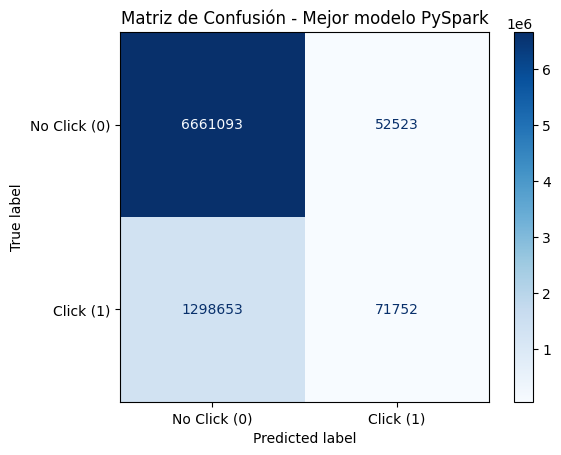

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

mejor_iteracion = int(mejor_fila["iteracion"])
cm_csv_path = os.path.join(checkpoint_dir, f"cm_iter{mejor_iteracion}.csv")

cm_raw = pd.read_csv(cm_csv_path)
print(cm_raw)  # columnas: click, prediction, count

# Reconstruir la matriz 2x2 en el orden [[TN, FP], [FN, TP]]
def construir_cm(cm_raw):
    cm = np.zeros((2, 2), dtype=int)
    for _, fila in cm_raw.iterrows():
        real = int(fila["click"])
        pred = int(fila["prediction"])
        cm[real, pred] = int(fila["count"])
    return cm

cm_spark = construir_cm(cm_raw)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_spark, display_labels=["No Click (0)", "Click (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión - Mejor modelo PySpark")
plt.savefig("../data/cm_pyspark_mejor_modelo.png", dpi=150, bbox_inches="tight")
plt.show()

La matriz de confusión muestra el desempeño del mejor modelo PySpark en la clasificación de No Click (0) y Click (1). El modelo clasificó correctamente 6.66 millones de casos sin click y 71.752 mil casos con click. Sin embargo, presentó 52.523 mil falsos positivos y 1.29 millones de falsos negativos.  
Se observa que el modelo tiene mayor dificultad para identificar correctamente los casos de Click (1), lo que concuerda con el bajo Recall obtenido durante la evaluación. Esto evidencia el efecto del desbalance de clases presente en el conjunto de datos.  

## Curva Roc  

In [ ]:
from pyspark.ml.functions import vector_to_array
import pyspark.sql.functions as F
import numpy as np
import matplotlib.pyplot as plt

# 1. Extraer la probabilidad de "click" SIN usar RDD/Python UDF

predictions = mejor_modelo.transform(test_final).select("click", "probability")
predictions = predictions.withColumn("prob_click", vector_to_array(F.col("probability"))[1])
predictions = predictions.persist(StorageLevel.MEMORY_AND_DISK)

# 2. Agregar en bins (histograma) — todo dentro de Spark, sin RDD
n_bins = 200
predictions_binned = predictions.withColumn(
    "bin", F.least(F.floor(F.col("prob_click") * n_bins), F.lit(n_bins - 1)).cast("int")
)

conteo_bins = predictions_binned.groupBy("bin", "click").count().toPandas() 

# 3. Reconstruir la curva ROC en pandas a partir de los conteos por bin

pivot = conteo_bins.pivot_table(index="bin", columns="click", values="count", fill_value=0)
pivot = pivot.reindex(range(n_bins), fill_value=0)

for clase in [0, 1]:
    if clase not in pivot.columns:
        pivot[clase] = 0
pivot = pivot[[0, 1]]
pivot.columns = ["neg", "pos"]

total_pos = pivot["pos"].sum()
total_neg = pivot["neg"].sum()

# Orden descendente de score (bin más alto = umbral más exigente primero)
pivot_desc = pivot.sort_index(ascending=False)
tp_cum = pivot_desc["pos"].cumsum()
fp_cum = pivot_desc["neg"].cumsum()

tpr_spark = [0.0] + (tp_cum / total_pos).tolist()
fpr_spark = [0.0] + (fp_cum / total_neg).tolist()

# AUC ya la tienes calculada de forma segura (BinaryClassificationEvaluator, sin RDD)
auc_spark = float(mejor_fila["roc_auc"])

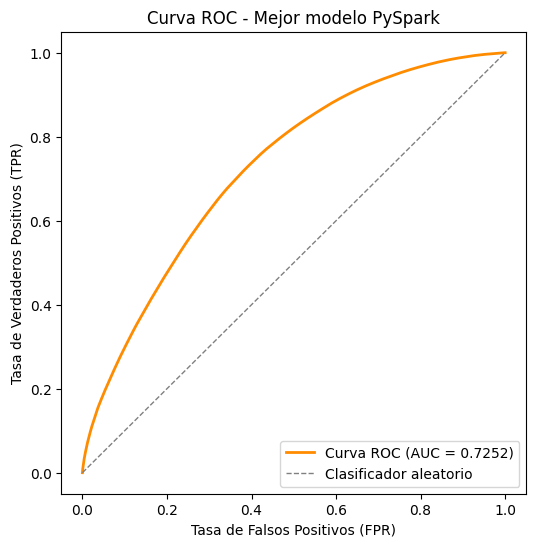

DataFrame[click: int, probability: vector, prob_click: double]

In [ ]:
# 4. Graficar
plt.figure(figsize=(6, 6))
plt.plot(fpr_spark, tpr_spark, color="darkorange", lw=2, label=f"Curva ROC (AUC = {auc_spark:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Clasificador aleatorio")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Mejor modelo PySpark")
plt.legend(loc="lower right")
plt.savefig("../data/roc_pyspark_mejor_modelo.png", dpi=150, bbox_inches="tight")
plt.show()

predictions.unpersist()

La curva ROC muestra la capacidad del mejor modelo PySpark para distinguir entre las clases Click (1) y No Click (0). El modelo obtuvo un ROC AUC de 0.7252, ubicándose por encima del clasificador aleatorio, representado por la línea diagonal. Esto indica que el modelo posee una capacidad de discriminación moderada, aunque todavía presenta dificultades para separar correctamente ambas clases.

In [40]:
import numpy as np

np.savez("../models/roc_curve_pyspark.npz", fpr=np.array(fpr_spark), tpr=np.array(tpr_spark), auc=auc_spark)
print("Curva ROC de PySpark guardada.")

Curva ROC de PySpark guardada.
